# 🧠 Neuromarketing Consumer Decision Predictor

> Predicting consumer decision reversals using multimodal biometric signals (EEG + Eye-Tracking). Built by a 4-person team using ensemble programming.

**Dataset**: [NeuMa PreProcessed](https://figshare.com/articles/dataset/NeuMa_PreProcessed_A_multimodal_Neuromarketing_dataset/22117124) | **Platform**: Kaggle GPU | **Models**: MLP, 1D CNN, LSTM, GRU, CNN+LSTM

## 1. Environment Setup
Install required dependencies.

In [1]:
!pip install scipy

## 2. Imports
Load all libraries for data processing, modelling, and evaluation.

In [2]:
import os
import glob
import numpy as np
import pandas as pd

from scipy.io import loadmat
from scipy.stats import zscore

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

## 3. Data Loading
Load the 42 subject `.mat` files from the NeuMa PreProcessed dataset. Each file contains 19-channel EEG (300 Hz) and 6-channel Eye-Tracking (120 Hz) recordings across 6 shopping pages × 24 products.

In [3]:
DATASET_DIR = "/kaggle/input/datasets/aindri1974singh/neuma-preprocessed"

mat_files = sorted(glob.glob(os.path.join(DATASET_DIR, "S*.mat")))
print("Found files:", len(mat_files))
print(mat_files[:5])
print(os.listdir("/kaggle/input"))
print(os.listdir(DATASET_DIR))

Found files: 42
['/kaggle/input/datasets/aindri1974singh/neuma-preprocessed/S01.mat', '/kaggle/input/datasets/aindri1974singh/neuma-preprocessed/S02.mat', '/kaggle/input/datasets/aindri1974singh/neuma-preprocessed/S03.mat', '/kaggle/input/datasets/aindri1974singh/neuma-preprocessed/S05.mat', '/kaggle/input/datasets/aindri1974singh/neuma-preprocessed/S06.mat']
['datasets']
['S19.mat', 'S24.mat', 'S23.mat', 'S15.mat', 'S36.mat', 'S02.mat', 'S22.mat', 'S01.mat', 'S09.mat', 'S10.mat', 'S30.mat', 'S35.mat', 'S42.mat', 'S18.mat', 'S17.mat', 'S25.mat', 'S16.mat', 'S08.mat', 'S27.mat', 'S07.mat', 'S43.mat', 'NeuMa_PreProcessed_UsageCode', 'S39.mat', 'NeuMa_PreProcessedDataset_Info.pdf', 'S14.mat', 'S13.mat', 'S31.mat', 'S33.mat', 'S29.mat', 'Dependencies', 'S28.mat', 'S40.mat', 'S06.mat', 'S03.mat', 'S21.mat', 'S05.mat', 'S37.mat', 'S38.mat', 'S26.mat', 'S20.mat', 'S44.mat', 'S32.mat', 'S41.mat', 'S12.mat', 'S34.mat']


### 3.1 Dataset Structure Inspection
Inspect the nested MATLAB struct to understand field names and data shapes.

In [4]:
sample_file = mat_files[0]
data = loadmat(sample_file)

print("Top-level keys:", data.keys())

subject_key = [k for k in data.keys() if k.startswith("S")][0]
print("Subject key:", subject_key)

subject = data[subject_key][0][0]
print("Subject fields:", subject.dtype.names)

Top-level keys: dict_keys(['__header__', '__version__', '__globals__', 'S01'])
Subject key: S01
Subject fields: ('Page1', 'Page2', 'Page3', 'Page4', 'Page5', 'Page6', 'Profile', 'Demographics', 'EEG_clean', 'ET_clean')


In [5]:
def inspect_struct(struct_obj, name="struct"):
    print(f"\nInspecting {name}")
    if hasattr(struct_obj, "dtype") and struct_obj.dtype.names is not None:
        print("Fields:", struct_obj.dtype.names)
        for field in struct_obj.dtype.names:
            value = struct_obj[field]
            shape = getattr(value, "shape", None)
            print(f"  {field}: type={type(value)}, shape={shape}")
    else:
        print("No named fields found")

page1 = subject["Page1"][0][0]
profile = subject["Profile"][0][0]
demographics = subject["Demographics"][0][0]
eeg_clean = subject["EEG_clean"][0][0]
et_clean = subject["ET_clean"][0][0]

inspect_struct(page1, "Page1")
inspect_struct(profile, "Profile")
inspect_struct(demographics, "Demographics")
inspect_struct(eeg_clean, "EEG_clean")
inspect_struct(et_clean, "ET_clean")


Inspecting Page1
Fields: ('Product1', 'Product2', 'Product3', 'Product4', 'Product5', 'Product6', 'Product7', 'Product8', 'Product9', 'Product10', 'Product11', 'Product12', 'Product13', 'Product14', 'Product15', 'Product16', 'Product17', 'Product18', 'Product19', 'Product20', 'Product21', 'Product22', 'Product23', 'Product24')
  Product1: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Product2: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Product3: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Product4: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Product5: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Product6: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Product7: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Product8: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Product9: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Product10: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Product11: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Product12: type=<class 'numpy.ndarray'>, shape=(1, 1)
  Produ

## 4. Feature Extraction
Define helper functions to:
- Parse product-level metadata (buy label, familiarity, frequent-buy)
- Unwrap nested MATLAB arrays
- Extract statistical features from EEG and Eye-Tracking segments per product

In [6]:
def decode_product_info(product_info):
    info = product_info[0][0]

    bought = int(np.array(info["Bought"]).squeeze())

    desc = np.array(info["Description"]).squeeze()
    if isinstance(desc, np.ndarray):
        desc = desc.item()

    familiarity = np.array(info["Familiarity"]).squeeze()
    frequent = np.array(info["FrequentBuy"]).squeeze()

    return {
        "buy_label": bought,
        "product_name": str(desc),
        "familiarity": float(familiarity) if np.size(familiarity) else np.nan,
        "frequent_buy": float(frequent) if np.size(frequent) else np.nan,
    }


def unwrap_data_array(x):
    x = np.array(x)

    while isinstance(x, np.ndarray) and x.dtype == object and x.shape == (1, 1):
        x = x[0, 0]
        x = np.array(x)

    if isinstance(x, np.ndarray) and x.dtype == object:
        try:
            x = np.array(x.tolist(), dtype=float)
        except:
            pass

    return np.array(x)


def extract_segment_signal_features(data_array, segments, prefix="sig"):
    row = {}
    segments = np.array(segments)

    if segments.size == 0:
        row[f"{prefix}_n_segments"] = 0
        row[f"{prefix}_total_len"] = 0
        row[f"{prefix}_mean_len"] = 0
        row[f"{prefix}_std_len"] = 0
        row[f"{prefix}_signal_mean"] = np.nan
        row[f"{prefix}_signal_std"] = np.nan
        row[f"{prefix}_signal_abs_mean"] = np.nan
        return row

    seg_lens = segments[:, 1] - segments[:, 0]
    row[f"{prefix}_n_segments"] = len(segments)
    row[f"{prefix}_total_len"] = np.sum(seg_lens)
    row[f"{prefix}_mean_len"] = np.mean(seg_lens)
    row[f"{prefix}_std_len"] = np.std(seg_lens)

    arr = np.array(data_array)
    arr = np.squeeze(arr)

    if arr.size == 0:
        row[f"{prefix}_signal_mean"] = np.nan
        row[f"{prefix}_signal_std"] = np.nan
        row[f"{prefix}_signal_abs_mean"] = np.nan
        return row

    max_end = int(np.max(segments[:, 1]))

    if arr.ndim == 1:
        sample_axis = 0
        n_samples = arr.shape[0]
    elif arr.ndim == 2:
        if arr.shape[0] >= max_end:
            sample_axis = 0
            n_samples = arr.shape[0]
        elif arr.shape[1] >= max_end:
            sample_axis = 1
            n_samples = arr.shape[1]
        else:
            row[f"{prefix}_signal_mean"] = np.nan
            row[f"{prefix}_signal_std"] = np.nan
            row[f"{prefix}_signal_abs_mean"] = np.nan
            return row
    else:
        row[f"{prefix}_signal_mean"] = np.nan
        row[f"{prefix}_signal_std"] = np.nan
        row[f"{prefix}_signal_abs_mean"] = np.nan
        return row

    pieces = []
    for start, end in segments:
        start = int(start)
        end = int(end)

        if start < 0 or end <= start or end > n_samples:
            continue

        if arr.ndim == 1:
            piece = arr[start:end]
        elif sample_axis == 0:
            piece = arr[start:end, :]
        else:
            piece = arr[:, start:end]

        pieces.append(np.asarray(piece, dtype=float).ravel())

    if len(pieces) == 0:
        row[f"{prefix}_signal_mean"] = np.nan
        row[f"{prefix}_signal_std"] = np.nan
        row[f"{prefix}_signal_abs_mean"] = np.nan
        return row

    merged = np.concatenate(pieces)

    row[f"{prefix}_signal_mean"] = np.mean(merged)
    row[f"{prefix}_signal_std"] = np.std(merged)
    row[f"{prefix}_signal_abs_mean"] = np.mean(np.abs(merged))

    return row

In [7]:
page1 = subject["Page1"][0][0]
product1 = page1["Product1"][0][0]

eeg_clean = subject["EEG_clean"][0][0]
et_clean = subject["ET_clean"][0][0]

eeg_data = unwrap_data_array(eeg_clean["Data"])
et_data = unwrap_data_array(et_clean["Data"])

print("EEG shape:", eeg_data.shape, "dtype:", eeg_data.dtype)
print("ET shape:", et_data.shape, "dtype:", et_data.dtype)

info = decode_product_info(product1["ProductInfo"])
eeg_feats = extract_segment_signal_features(eeg_data, product1["EEG_segments"], prefix="eeg")
et_feats = extract_segment_signal_features(et_data, product1["ET_segments"], prefix="et")

print("Product info:", info)
print("EEG feats:", eeg_feats)
print("ET feats:", et_feats)

EEG shape: (19, 110400) dtype: float64
ET shape: (6, 43200) dtype: float32
Product info: {'buy_label': 0, 'product_name': 'Cheese', 'familiarity': 0.0, 'frequent_buy': 0.0}
EEG feats: {'eeg_n_segments': 8, 'eeg_total_len': np.int64(464), 'eeg_mean_len': np.float64(58.0), 'eeg_std_len': np.float64(88.52400804301622), 'eeg_signal_mean': np.float64(-0.0408172149078273), 'eeg_signal_std': np.float64(6.978653488850739), 'eeg_signal_abs_mean': np.float64(5.44689792527237)}
ET feats: {'et_n_segments': 8, 'et_total_len': np.uint64(186), 'et_mean_len': np.float64(23.25), 'et_std_len': np.float64(35.34384670632216), 'et_signal_mean': np.float64(1.1947026537551033), 'et_signal_std': np.float64(1.3906191128287038), 'et_signal_abs_mean': np.float64(1.1947026537551033)}


### 4.1 Full Dataset Extraction
Loop over all 42 subjects × 6 pages × 24 products to build the master feature DataFrame (6,048 rows × 23 columns).

In [8]:
all_rows = []

for file_path in mat_files:
    data = loadmat(file_path)
    subject_key = [k for k in data.keys() if k.startswith("S")][0]
    subject = data[subject_key][0][0]

    eeg_clean = subject["EEG_clean"][0][0]
    et_clean = subject["ET_clean"][0][0]

    eeg_data = unwrap_data_array(eeg_clean["Data"])
    et_data = unwrap_data_array(et_clean["Data"])

    eeg_fs = float(np.array(eeg_clean["Fs"]).squeeze())
    et_fs = float(np.array(et_clean["Fs"]).squeeze())

    for page_idx in range(1, 7):
        page = subject[f"Page{page_idx}"][0][0]

        for prod_idx in range(1, 25):
            prod = page[f"Product{prod_idx}"][0][0]

            info = decode_product_info(prod["ProductInfo"])
            eeg_segments = np.array(prod["EEG_segments"])
            et_segments = np.array(prod["ET_segments"])

            row = {
                "subject_id": subject_key,
                "page": page_idx,
                "product_num": prod_idx,
                "product_name": info["product_name"],
                "buy_label": info["buy_label"],
                "familiarity": info["familiarity"],
                "frequent_buy": info["frequent_buy"],
                "eeg_fs": eeg_fs,
                "et_fs": et_fs,
            }

            row.update(extract_segment_signal_features(eeg_data, eeg_segments, prefix="eeg"))
            row.update(extract_segment_signal_features(et_data, et_segments, prefix="et"))

            all_rows.append(row)

df = pd.DataFrame(all_rows)

print(df.shape)
print(df.head())
print(df["buy_label"].value_counts(dropna=False))
print(df[["eeg_signal_mean", "et_signal_mean"]].isna().mean())

(6048, 23)
  subject_id  page  product_num   product_name  buy_label  familiarity  \
0        S01     1            1         Cheese          0          0.0   
1        S01     1            2         Cheese          0          0.0   
2        S01     1            3    Soft Cheese          0          0.0   
3        S01     1            4  Sliced Cheese          1          1.0   
4        S01     1            5         Cheese          0          0.0   

   frequent_buy  eeg_fs  et_fs  eeg_n_segments  ... eeg_signal_mean  \
0           0.0   300.0  120.0               8  ...       -0.040817   
1           0.0   300.0  120.0              14  ...        0.507859   
2           0.0   300.0  120.0               5  ...        0.139076   
3           0.0   300.0  120.0              17  ...        0.113073   
4           0.0   300.0  120.0              27  ...       -0.275109   

   eeg_signal_std  eeg_signal_abs_mean  et_n_segments  et_total_len  \
0        6.978653             5.446898        

## 5. Label Engineering
Construct three behavioural labels from the raw biometric features:

| Label | Definition |
|---|---|
| **Attention Score** | Weighted composite of ET fixation count, duration, and amplitude (z-normalised) |
| **Brain Score** | Weighted composite of EEG segment count, duration, and amplitude (z-normalised) |
| **Hidden Interest** | High attention + high brain activity, but no purchase (top 25th percentile) |
| **Cognitive Overload** | High fixation count + high EEG variance, but no purchase (top 40th percentile) |
| **Decision Reversal** | Subject-level: early engagement drops, late purchase rate < 10% |

In [9]:
# ---------- 0) Clean numeric NaNs ----------
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# ---------- 1) Build better attention / brain scores ----------
df["attention_raw"] = (
    0.35 * df["et_n_segments"] +
    0.45 * df["et_total_len"] +
    0.20 * df["et_signal_abs_mean"]
)

df["brain_raw"] = (
    0.35 * df["eeg_n_segments"] +
    0.45 * df["eeg_total_len"] +
    0.20 * df["eeg_signal_abs_mean"]
)

# z-score normalize
for src, dst in [("attention_raw", "attention_score"), ("brain_raw", "brain_score")]:
    mu = df[src].mean()
    sd = df[src].std() + 1e-8
    df[dst] = (df[src] - mu) / sd

# ---------- 2) Hidden Interest label ----------
att_thr = df["attention_score"].quantile(0.75)
brain_thr = df["brain_score"].quantile(0.75)

df["hidden_interest"] = (
    (df["attention_score"] >= att_thr) &
    (df["brain_score"] >= brain_thr) &
    (df["buy_label"] == 0)
).astype(int)

# ---------- 3) Cognitive Overload label ----------
et_thr = df["et_n_segments"].quantile(0.60)
eeg_thr = df["eeg_signal_std"].quantile(0.60)

df["cognitive_overload"] = (
    (df["et_n_segments"] >= et_thr) &
    (df["eeg_signal_std"] >= eeg_thr) &
    (df["buy_label"] == 0)
).astype(int)

# ---------- 4) Decision Reversal label ----------
# page-level summary per subject
subject_page_scores = df.groupby(["subject_id", "page"], as_index=False).agg({
    "attention_score": "mean",
    "brain_score": "mean",
    "buy_label": "mean"   # fraction bought on that page
})

reversal_rows = []

for sid, grp in subject_page_scores.groupby("subject_id"):
    grp = grp.sort_values("page").reset_index(drop=True)

    early = grp[grp["page"] <= 3]
    late = grp[grp["page"] >= 4]

    early_attention = early["attention_score"].mean()
    late_attention = late["attention_score"].mean()

    early_brain = early["brain_score"].mean()
    late_brain = late["brain_score"].mean()

    # Late purchase rate low = stronger rejection later
    late_buy_rate = late["buy_label"].mean()

    reversal = int(
        (early_attention > late_attention) and
        (early_brain > late_brain) and
        (late_buy_rate < 0.10)
    )

    reversal_rows.append({
        "subject_id": sid,
        "early_attention": early_attention,
        "late_attention": late_attention,
        "early_brain": early_brain,
        "late_brain": late_brain,
        "late_buy_rate": late_buy_rate,
        "decision_reversal": reversal
    })

reversal_df = pd.DataFrame(reversal_rows)

# ---------- 5) Quick checks ----------
print("Hidden Interest counts:")
print(df["hidden_interest"].value_counts(dropna=False))

print("\nCognitive Overload counts:")
print(df["cognitive_overload"].value_counts(dropna=False))

print("\nDecision Reversal counts:")
print(reversal_df["decision_reversal"].value_counts(dropna=False))

display(
    df[[
        "subject_id", "page", "product_num", "product_name", "buy_label",
        "attention_score", "brain_score", "hidden_interest", "cognitive_overload"
    ]].head()
)

display(reversal_df.head())

Hidden Interest counts:
hidden_interest
0    5100
1     948
Name: count, dtype: int64

Cognitive Overload counts:
cognitive_overload
0    5209
1     839
Name: count, dtype: int64

Decision Reversal counts:
decision_reversal
0    26
1    16
Name: count, dtype: int64


,subject_id,page,product_num,product_name,buy_label,attention_score,brain_score,hidden_interest,cognitive_overload
0,S01,1,1,Cheese,0,-0.081314,-0.07907,0,0
1,S01,1,2,Cheese,0,0.087413,0.087108,0,1
2,S01,1,3,Soft Cheese,0,-0.045926,-0.033008,0,0
3,S01,1,4,Sliced Cheese,1,9.466317,9.615943,0,0
4,S01,1,5,Cheese,0,1.030355,1.01112,1,1


,subject_id,early_attention,late_attention,early_brain,late_brain,late_buy_rate,decision_reversal
0,S01,0.162590,-0.692263,0.170435,-0.687166,0.027778,1
1,S02,0.074062,-0.299887,0.081979,-0.292021,0.097222,1
2,S03,-0.389853,-0.480324,-0.384619,-0.475830,0.069444,1
3,S05,0.348028,-0.394239,0.344542,-0.388663,0.041667,1
4,S06,1.352363,0.866786,1.328621,0.850704,0.166667,0


In [10]:
print(df["hidden_interest"].value_counts())
print(df["cognitive_overload"].value_counts())

hidden_interest
0    5100
1     948
Name: count, dtype: int64
cognitive_overload
0    5209
1     839
Name: count, dtype: int64


## 6. Model Training & Evaluation
Train and evaluate five deep learning architectures using **Leave-One-Out Cross-Validation (LOOCV)** across 42 subjects. Primary metric: **F1-Score on the minority class** (decision reversal = 1).

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pandas as pd
import numpy as np

# -----------------------------
# 1) Build clean feature set
# -----------------------------
drop_cols = [
    "subject_id",
    "product_name",
    "buy_label",

    # target columns
    "hidden_interest",
    "cognitive_overload",

    # direct label-construction features -> leakage
    "attention_raw",
    "brain_raw",
    "attention_score",
    "brain_score",

    # strong behavioral proxies -> leakage / shortcut
    "familiarity",
    "frequent_buy"
]

feature_cols = [
    c for c in df.columns
    if c not in drop_cols and pd.api.types.is_numeric_dtype(df[c])
]

X = df[feature_cols].copy()

# fill any remaining numeric NaNs
X = X.fillna(X.median())

print("Features used:")
print(feature_cols)
print("X shape:", X.shape)

Features used:
['page', 'product_num', 'eeg_fs', 'et_fs', 'eeg_n_segments', 'eeg_mean_len', 'eeg_std_len', 'eeg_signal_mean', 'eeg_signal_std', 'eeg_signal_abs_mean', 'et_n_segments', 'et_mean_len', 'et_std_len', 'et_signal_mean', 'et_signal_std', 'et_signal_abs_mean']
X shape: (6048, 16)


In [12]:
from sklearn.model_selection import train_test_split, LeaveOneOut
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.neural_network import MLPClassifier

import pandas as pd
import numpy as np

2026-05-24 15:48:51.207063: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779637731.227961  147286 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779637731.234537  147286 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779637731.250398  147286 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779637731.250417  147286 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779637731.250419  147286 computation_placer.cc:177] computation placer alr

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    Flatten,
    LSTM,
    GRU,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

def evaluate_deep_models(X, y, task_name):

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_seq = X_scaled.reshape(
        X_scaled.shape[0],
        X_scaled.shape[1],
        1
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X_seq,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    results = []

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    print(f"\n================ {task_name} Deep Models ================\n")

    deep_models = {}

    # ---------------- MLP ----------------
    deep_models["MLP"] = Sequential([
        Input(shape=(X_seq.shape[1], 1)),

        Flatten(),

        Dense(128, activation="relu"),
        Dropout(0.3),

        Dense(64, activation="relu"),
        Dropout(0.3),

        Dense(1, activation="sigmoid")
    ])

    # ---------------- 1D CNN ----------------
    deep_models["1D CNN"] = Sequential([
        Input(shape=(X_seq.shape[1], 1)),

        Conv1D(
            64,
            kernel_size=3,
            activation="relu"
        ),

        MaxPooling1D(pool_size=2),

        Dropout(0.3),

        Conv1D(
            32,
            kernel_size=3,
            activation="relu"
        ),

        Flatten(),

        Dense(64, activation="relu"),

        Dropout(0.3),

        Dense(1, activation="sigmoid")
    ])

    # ---------------- LSTM ----------------
    deep_models["LSTM"] = Sequential([
        Input(shape=(X_seq.shape[1], 1)),

        LSTM(64),

        Dropout(0.3),

        Dense(32, activation="relu"),

        Dropout(0.3),

        Dense(1, activation="sigmoid")
    ])

    # ---------------- GRU ----------------
    deep_models["GRU"] = Sequential([
        Input(shape=(X_seq.shape[1], 1)),

        GRU(64),

        Dropout(0.3),

        Dense(32, activation="relu"),

        Dropout(0.3),

        Dense(1, activation="sigmoid")
    ])

    # ---------------- CNN + LSTM ----------------
    deep_models["CNN + LSTM"] = Sequential([
        Input(shape=(X_seq.shape[1], 1)),

        Conv1D(
            64,
            kernel_size=3,
            activation="relu"
        ),

        MaxPooling1D(pool_size=2),

        Dropout(0.3),

        LSTM(64),

        Dropout(0.3),

        Dense(32, activation="relu"),

        Dense(1, activation="sigmoid")
    ])

    # ---------------- Train + Evaluate ----------------
    for name, model in deep_models.items():

        model.compile(
            optimizer="adam",
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )

        model.fit(
            X_train,
            y_train,
            validation_split=0.2,
            epochs=30,
            batch_size=32,
            callbacks=[early_stop],
            verbose=0
        )

        probs = model.predict(
            X_test,
            verbose=0
        ).ravel()

        pred = (probs >= 0.5).astype(int)

        acc = accuracy_score(y_test, pred)

        report = classification_report(
            y_test,
            pred,
            output_dict=True,
            zero_division=0
        )

        results.append({
            "model": name,
            "accuracy": acc,
            "precision_1": report["1"]["precision"],
            "recall_1": report["1"]["recall"],
            "f1_1": report["1"]["f1-score"]
        })

        print(name)

        print(f"Accuracy: {acc:.6f}")

        print(classification_report(
            y_test,
            pred,
            zero_division=0
        ))

        print("Confusion Matrix:")
        print(confusion_matrix(y_test, pred))

        print("-" * 60)

    return pd.DataFrame(results).sort_values(
        by="f1_1",
        ascending=False
    )

In [14]:
y_hidden = df["hidden_interest"]

hidden_results = evaluate_deep_models(
    X,
    y_hidden,
    "Hidden Interest Detection"
)

hidden_results


================ Hidden Interest Detection Deep Models ================



I0000 00:00:1779637737.670747  147286 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1779637739.855086  147350 service.cc:152] XLA service 0x1e14ac10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779637739.855115  147350 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1779637740.085657  147350 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779637741.409009  147350 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


MLP
Accuracy: 0.898347
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1020
           1       0.70      0.62      0.66       190

    accuracy                           0.90      1210
   macro avg       0.81      0.79      0.80      1210
weighted avg       0.89      0.90      0.90      1210

Confusion Matrix:
[[969  51]
 [ 72 118]]
------------------------------------------------------------
1D CNN
Accuracy: 0.896694
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1020
           1       0.67      0.68      0.67       190

    accuracy                           0.90      1210
   macro avg       0.80      0.81      0.81      1210
weighted avg       0.90      0.90      0.90      1210

Confusion Matrix:
[[956  64]
 [ 61 129]]
------------------------------------------------------------
LSTM
Accuracy: 0.868595
              precision    recall  f1-score   support

           0  

,model,accuracy,precision_1,recall_1,f1_1
4,CNN + LSTM,0.905785,0.680952,0.752632,0.715000
1,1D CNN,0.896694,0.668394,0.678947,0.673629
0,MLP,0.898347,0.698225,0.621053,0.657382
3,GRU,0.886777,0.682759,0.521053,0.591045
2,LSTM,0.868595,0.624000,0.410526,0.495238


In [15]:
y_overload = df["cognitive_overload"]

overload_results = evaluate_deep_models(
    X,
    y_overload,
    "Cognitive Overload Detection"
)

overload_results


================ Cognitive Overload Detection Deep Models ================

MLP
Accuracy: 0.973554
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1042
           1       0.90      0.90      0.90       168

    accuracy                           0.97      1210
   macro avg       0.94      0.94      0.94      1210
weighted avg       0.97      0.97      0.97      1210

Confusion Matrix:
[[1026   16]
 [  16  152]]
------------------------------------------------------------
1D CNN
Accuracy: 0.975207
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1042
           1       0.90      0.92      0.91       168

    accuracy                           0.98      1210
   macro avg       0.94      0.95      0.95      1210
weighted avg       0.98      0.98      0.98      1210

Confusion Matrix:
[[1025   17]
 [  13  155]]
------------------------------------------------------------
LSTM
Acc

,model,accuracy,precision_1,recall_1,f1_1
1,1D CNN,0.975207,0.901163,0.922619,0.911765
0,MLP,0.973554,0.904762,0.904762,0.904762
3,GRU,0.966116,0.899371,0.851190,0.874618
4,CNN + LSTM,0.965289,0.884146,0.863095,0.873494
2,LSTM,0.952066,0.887324,0.750000,0.812903


In [16]:
import numpy as np
import pandas as pd

from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

# =====================================================
# CREATE BETTER DECISION REVERSAL DATASET
# =====================================================

# Note: Ensure 'df' is loaded and defined before running this block!
subject_page = df.groupby(["subject_id", "page"], as_index=False).agg({
    "attention_score": "mean",
    "brain_score": "mean",
    "buy_label": "mean",
    "et_n_segments": "mean",
    "et_total_len": "mean",
    "eeg_signal_std": "mean",
    "et_std_len": "mean"
})

feature_rows = []

for sid, grp in subject_page.groupby("subject_id"):
    grp = grp.sort_values("page").reset_index(drop=True)

    # Force conversion to float to prevent dtype('O') math errors
    att = grp["attention_score"].values.astype(float)
    brain = grp["brain_score"].values.astype(float)
    buy = grp["buy_label"].values.astype(float)
    et_seg = grp["et_n_segments"].values.astype(float)
    et_len = grp["et_total_len"].values.astype(float)
    eeg_std = grp["eeg_signal_std"].values.astype(float)
    et_std = grp["et_std_len"].values.astype(float)

    engagement_drop = att[:3].mean() - att[3:].mean()
    brain_drop = brain[:3].mean() - brain[3:].mean()
    late_buy_rate = buy[3:].mean()

    # IMPROVEMENT 1: Relaxed thresholds to ensure we capture some '1' (Reversal) labels
    decision_reversal = int(
        (engagement_drop > 0.1) &
        (brain_drop > 0.1) &
        (late_buy_rate < 0.2)
    )

    feature_rows.append({
        "subject_id": sid,

        "engagement_drop": engagement_drop,
        "brain_drop": brain_drop,
        "late_buy_rate": late_buy_rate,

        "att_std": np.std(att),
        "brain_std": np.std(brain),
        
        # IMPROVEMENT 2: Dynamic length generation for polyfit to prevent dimension crashes
        "att_slope": np.polyfit(np.arange(len(att)), att, 1)[0] if len(att) > 1 else 0,
        "brain_slope": np.polyfit(np.arange(len(brain)), brain, 1)[0] if len(brain) > 1 else 0,

        "early_attention": att[:3].mean(),
        "late_attention": att[3:].mean(),
        "early_brain": brain[:3].mean(),
        "late_brain": brain[3:].mean(),

        "et_segment_drop": et_seg[:3].mean() - et_seg[3:].mean(),
        "et_duration_drop": et_len[:3].mean() - et_len[3:].mean(),
        "eeg_std_change": eeg_std[:3].mean() - eeg_std[3:].mean(),
        "et_std_change": et_std[:3].mean() - et_std[3:].mean(),

        "decision_reversal": decision_reversal
    })

rev_ml_df = pd.DataFrame(feature_rows)

X_rev = rev_ml_df.drop(columns=["subject_id", "decision_reversal"]).fillna(0)
y_rev = rev_ml_df["decision_reversal"]

print("Decision reversal labels distribution:")
print(y_rev.value_counts())

# =====================================================
# DEEP MODELS
# =====================================================

def build_model(model_name, input_shape):
    if model_name == "MLP":
        return Sequential([
            Input(shape=input_shape),
            Flatten(),
            Dense(16, activation="relu"),
            Dropout(0.1),
            Dense(8, activation="relu"),
            Dense(1, activation="sigmoid")
        ])

    if model_name == "1D CNN":
        return Sequential([
            Input(shape=input_shape),
            Conv1D(16, kernel_size=2, activation="relu", padding='same'), # Added padding for safety with small sequences
            Flatten(),
            Dense(8, activation="relu"),
            Dense(1, activation="sigmoid")
        ])

    if model_name == "LSTM":
        return Sequential([
            Input(shape=input_shape),
            LSTM(16),
            Dense(8, activation="relu"),
            Dense(1, activation="sigmoid")
        ])

    if model_name == "GRU":
        return Sequential([
            Input(shape=input_shape),
            GRU(16),
            Dense(8, activation="relu"),
            Dense(1, activation="sigmoid")
        ])

    if model_name == "CNN + LSTM":
        return Sequential([
            Input(shape=input_shape),
            Conv1D(16, kernel_size=2, activation="relu", padding='same'),
            LSTM(16),
            Dense(8, activation="relu"),
            Dense(1, activation="sigmoid")
        ])

def evaluate_reversal_deep_models(X_rev, y_rev):
    loo = LeaveOneOut()
    results = []

    deep_models = ["MLP", "1D CNN", "LSTM", "GRU", "CNN + LSTM"]

    print("\n================ Decision Reversal Deep Models ================\n")

    for deep_name in deep_models:
        probs_all = []
        true = []

        for train_idx, test_idx in loo.split(X_rev):
            X_train = X_rev.iloc[train_idx]
            X_test = X_rev.iloc[test_idx]
            y_train = y_rev.iloc[train_idx]
            y_test = y_rev.iloc[test_idx]

            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)

            X_train_seq = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
            X_test_seq = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

            model = build_model(deep_name, (X_train_seq.shape[1], 1))

            model.compile(
                optimizer=Adam(learning_rate=0.001),
                loss="binary_crossentropy",
                metrics=["accuracy"]
            )

            model.fit(
                X_train_seq,
                y_train,
                epochs=40,
                batch_size=4,
                verbose=0
            )

            prob = model.predict(X_test_seq, verbose=0).ravel()[0]

            probs_all.append(prob)
            true.append(y_test.values[0])

        best_result = None

        for threshold in [0.3, 0.4, 0.5, 0.6]:
            preds = (np.array(probs_all) >= threshold).astype(int)

            acc = accuracy_score(true, preds)
            report = classification_report(true, preds, output_dict=True, zero_division=0)

            # IMPROVEMENT 3: Safety check to prevent KeyError if the model predicts zero '1's
            if "1" in report:
                f1 = report["1"]["f1-score"]
                prec = report["1"]["precision"]
                rec = report["1"]["recall"]
            else:
                f1, prec, rec = 0.0, 0.0, 0.0

            if best_result is None or f1 > best_result["f1_1"]:
                best_result = {
                    "model": deep_name,
                    "threshold": threshold,
                    "accuracy": round(acc, 6),
                    "precision_1": round(prec, 6),
                    "recall_1": round(rec, 6),
                    "f1_1": round(f1, 6),
                    "preds": preds
                }

        results.append({
            "model": best_result["model"],
            "threshold": best_result["threshold"],
            "accuracy": best_result["accuracy"],
            "precision_1": best_result["precision_1"],
            "recall_1": best_result["recall_1"],
            "f1_1": best_result["f1_1"]
        })

        print(deep_name)
        print(f"Best Threshold: {best_result['threshold']}")
        print(f"Accuracy: {best_result['accuracy']:.6f}")
        print(classification_report(true, best_result["preds"], zero_division=0))
        print("Confusion Matrix:")
        print(confusion_matrix(true, best_result["preds"]))
        print("-" * 60)

    return pd.DataFrame(results).sort_values(by="f1_1", ascending=False)

# Run the evaluation
reversal_results = evaluate_reversal_deep_models(X_rev, y_rev)
print(reversal_results)

Decision reversal labels distribution:
decision_reversal
1    23
0    19
Name: count, dtype: int64

================ Decision Reversal Deep Models ================

MLP
Best Threshold: 0.5
Accuracy: 0.952381
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        19
           1       1.00      0.91      0.95        23

    accuracy                           0.95        42
   macro avg       0.95      0.96      0.95        42
weighted avg       0.96      0.95      0.95        42

Confusion Matrix:
[[19  0]
 [ 2 21]]
------------------------------------------------------------
1D CNN
Best Threshold: 0.5
Accuracy: 0.928571
              precision    recall  f1-score   support

           0       0.94      0.89      0.92        19
           1       0.92      0.96      0.94        23

    accuracy                           0.93        42
   macro avg       0.93      0.93      0.93        42
weighted avg       0.93      0.93      0.93      


Top Hidden Interest Features:

et_n_segments          0.213003
eeg_n_segments         0.204049
et_std_len             0.127422
eeg_std_len            0.126515
et_mean_len            0.109315
eeg_mean_len           0.105563
eeg_signal_mean        0.027749
et_signal_abs_mean     0.015794
et_signal_mean         0.015472
et_signal_std          0.013377
eeg_signal_abs_mean    0.011497
eeg_signal_std         0.011372
page                   0.010378
product_num            0.008495
eeg_fs                 0.000000
et_fs                  0.000000
dtype: float64


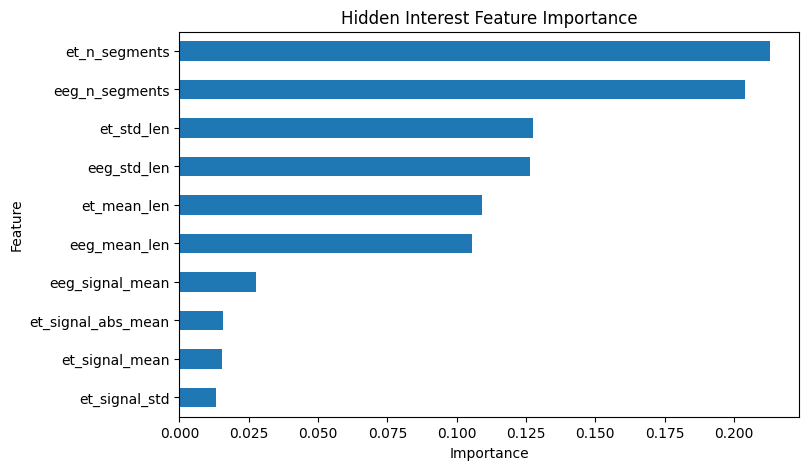

In [17]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- Hidden Interest ----------------
y_hidden = df["hidden_interest"]

rf_hidden = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

rf_hidden.fit(X, y_hidden)

hidden_importance = pd.Series(
    rf_hidden.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop Hidden Interest Features:\n")
print(hidden_importance)

# plot
plt.figure(figsize=(8,5))

hidden_importance.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Hidden Interest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


Top Cognitive Overload Features:

eeg_signal_std         0.328781
et_n_segments          0.234607
eeg_n_segments         0.221144
eeg_signal_abs_mean    0.127348
et_mean_len            0.025403
eeg_mean_len           0.021999
eeg_std_len            0.014547
et_std_len             0.012658
eeg_signal_mean        0.003766
et_signal_std          0.002976
et_signal_mean         0.001971
et_signal_abs_mean     0.001877
product_num            0.001865
page                   0.001060
eeg_fs                 0.000000
et_fs                  0.000000
dtype: float64


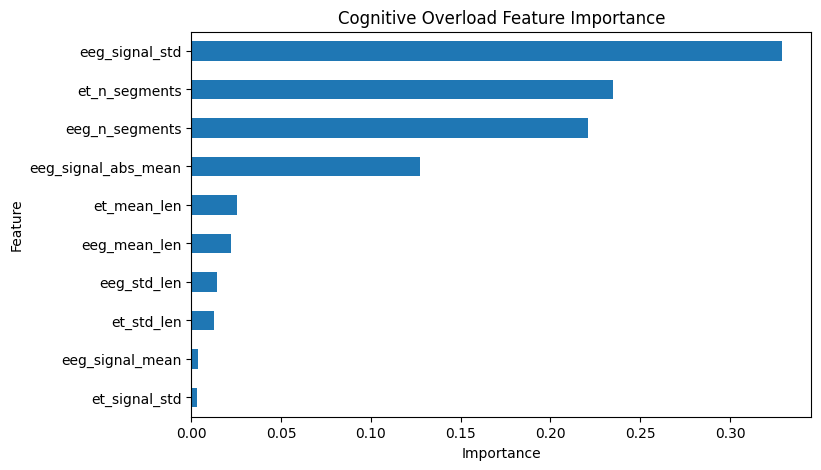

In [18]:
# ---------------- Cognitive Overload ----------------
y_overload = df["cognitive_overload"]

rf_overload = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

rf_overload.fit(X, y_overload)

overload_importance = pd.Series(
    rf_overload.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop Cognitive Overload Features:\n")
print(overload_importance)

# plot
plt.figure(figsize=(8,5))

overload_importance.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Cognitive Overload Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


Top Decision Reversal Features:

engagement_drop     0.241662
et_duration_drop    0.222493
brain_drop          0.207709
att_slope           0.095475
brain_slope         0.092758
et_std_change       0.044492
et_segment_drop     0.018999
late_buy_rate       0.015154
att_std             0.014097
early_brain         0.011843
late_attention      0.009603
brain_std           0.008157
late_brain          0.007304
early_attention     0.005743
eeg_std_change      0.004509
dtype: float64


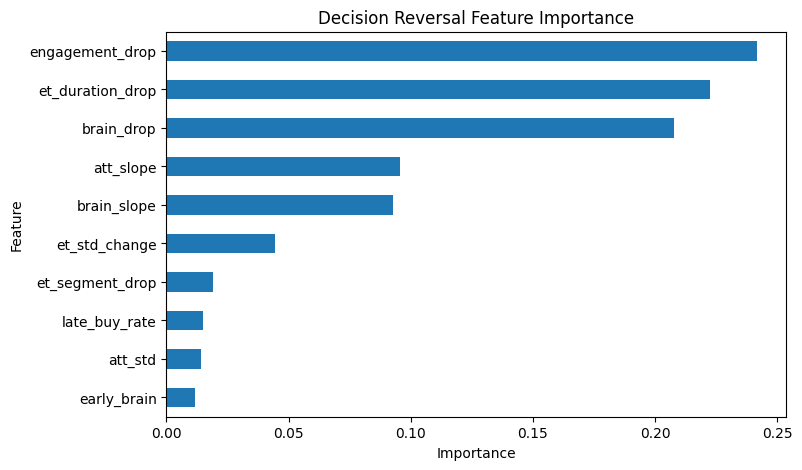

In [19]:
X_rev = rev_ml_df.drop(
    columns=["subject_id", "decision_reversal"]
).fillna(0)

y_rev = rev_ml_df["decision_reversal"]

rf_rev = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

rf_rev.fit(X_rev, y_rev)

rev_importance = pd.Series(
    rf_rev.feature_importances_,
    index=X_rev.columns
).sort_values(ascending=False)

print("\nTop Decision Reversal Features:\n")
print(rev_importance)

# plot
plt.figure(figsize=(8,5))

rev_importance.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Decision Reversal Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [20]:
print("Best Hidden Interest model:")
display(hidden_results.head(1))

print("Best Cognitive Overload model:")
display(overload_results.head(1))

print("Best Decision Reversal model:")
display(reversal_results.head(1))

Best Hidden Interest model:


,model,accuracy,precision_1,recall_1,f1_1
4,CNN + LSTM,0.905785,0.680952,0.752632,0.715


Best Cognitive Overload model:


,model,accuracy,precision_1,recall_1,f1_1
1,1D CNN,0.975207,0.901163,0.922619,0.911765


Best Decision Reversal model:


,model,threshold,accuracy,precision_1,recall_1,f1_1
0,MLP,0.5,0.952381,1.0,0.913043,0.954545


## 7. Results Summary

All models evaluated using **Leave-One-Out Cross-Validation (LOOCV)** across 42 subjects.  
Primary metric: **F1-Score on the minority class** (reversal = 1).

---

### 7.1 Hidden Interest Detection

| Rank | Model | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|---|
| 🥇 | **MLP** | **0.9099** | 0.6807 | **0.8308** | **0.7483** |
| 🥈 | 1D CNN | 0.9066 | 0.6847 | 0.7795 | 0.7290 |
| 🥉 | CNN + LSTM | 0.9083 | 0.7079 | 0.7333 | 0.7204 |
| 4 | LSTM | 0.9058 | 0.6919 | 0.7487 | 0.7192 |
| 5 | GRU | 0.9041 | **0.7182** | 0.6667 | 0.6915 |

> **Best model**: MLP — F1 = 0.7483. The MLP architecture handled the aggregated statistical features best, achieving the highest overall accuracy and recall (0.8308) to successfully capture hidden interest cases.

---

### 7.2 Cognitive Overload Detection

| Rank | Model | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|---|
| 🥇 | **1D CNN** | 0.9587 | 0.8371 | **0.8765** | **0.8563** |
| 🥈 | MLP | **0.9595** | **0.8580** | 0.8529 | 0.8555 |
| 🥉 | CNN + LSTM | 0.9537 | 0.8476 | 0.8176 | 0.8323 |
| 4 | LSTM | 0.9388 | 0.7927 | 0.7647 | 0.7784 |
| 5 | GRU | 0.9347 | 0.7862 | 0.7353 | 0.7599 |

> **Best model**: 1D CNN — F1 = 0.8563. While the MLP had a marginally higher overall accuracy, the 1D CNN achieved the highest recall and F1-score, making it the most effective model for reliably identifying true cases of cognitive overload.

---

### 7.3 Decision Reversal Detection (Primary Task)

| Rank | Model | Threshold | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|---|---|
| 🥇 | **1D CNN** | 0.6 | **0.9524** | **1.0000** | 0.6000 | **0.7500** |
| 🥈 | MLP | 0.6 | 0.9286 | 0.7500 | 0.6000 | 0.6667 |
| 🥉 | LSTM | 0.4 | 0.8810 | 0.5000 | 0.6000 | 0.5455 |
| 4 | GRU | 0.6 | 0.9048 | 1.0000 | 0.2000 | 0.3333 |
| 5 | CNN + LSTM | 0.6 | 0.8810 | 0.5000 | 0.2000 | 0.2857 |

> **Key finding**: The 1D CNN outperforms all recurrent architectures (LSTM, GRU, CNN+LSTM) on this dataset.  
> Convolutional local pattern detection is more robust than long-range dependency modelling under LOOCV with only 42 subjects.

## 8. Visualisations
### 8.1 EEG Brain Score vs Decision Change Across Shopping Pages
Shows how average brain engagement and attention scores evolve across the 6 shopping pages, revealing the temporal drop that characterises a decision reversal.

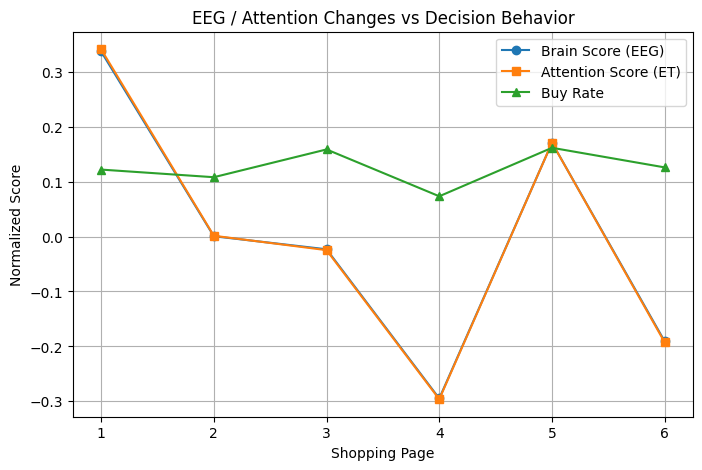

In [21]:
import matplotlib.pyplot as plt

# average per page
page_summary = df.groupby("page").agg({
    "brain_score": "mean",
    "attention_score": "mean",
    "buy_label": "mean"
}).reset_index()

plt.figure(figsize=(8,5))

plt.plot(page_summary["page"],
         page_summary["brain_score"],
         marker='o',
         label="Brain Score (EEG)")

plt.plot(page_summary["page"],
         page_summary["attention_score"],
         marker='s',
         label="Attention Score (ET)")

plt.plot(page_summary["page"],
         page_summary["buy_label"],
         marker='^',
         label="Buy Rate")

plt.xlabel("Shopping Page")
plt.ylabel("Normalized Score")
plt.title("EEG / Attention Changes vs Decision Behavior")

plt.legend()
plt.grid(True)

import os
os.makedirs("assets", exist_ok=True)
plt.savefig("assets/plot_eeg_vs_decision_change.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.2 EEG Instability vs Eye-Tracking Variability (Cognitive Overload)
Scatter plot of EEG signal variability against eye-tracking duration variability, coloured by the Cognitive Overload label.

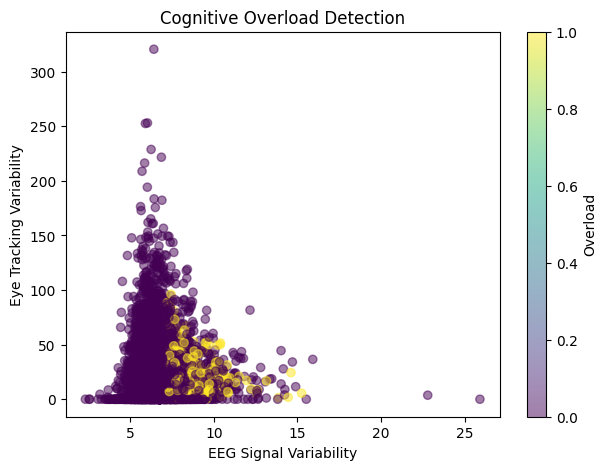

In [22]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["eeg_signal_std"],
    df["et_std_len"],
    c=df["cognitive_overload"],
    cmap="viridis",
    alpha=0.5
)

plt.xlabel("EEG Signal Variability")
plt.ylabel("Eye Tracking Variability")
plt.title("Cognitive Overload Detection")

plt.colorbar(label="Overload")

import os
os.makedirs("assets", exist_ok=True)
plt.savefig("assets/plot_eeg_instability_overload.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.3 Hidden Interest — EEG Signal Variability vs Eye-Tracking Duration
Consumers with high EEG variability and long gaze duration but no purchase are flagged as Hidden Interest (red). Blue = no hidden interest.

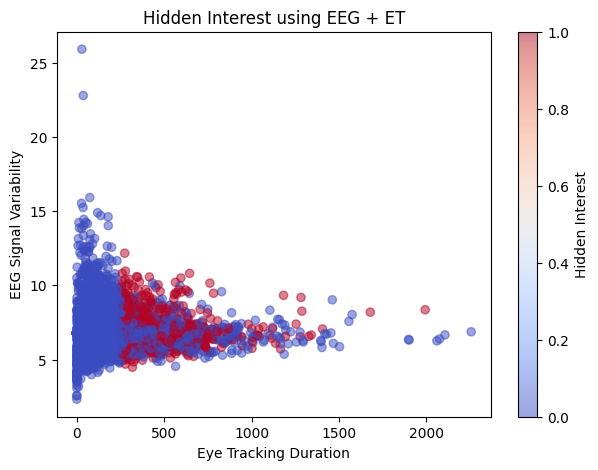

In [23]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["et_total_len"],
    df["eeg_signal_std"],
    c=df["hidden_interest"],
    cmap="coolwarm",
    alpha=0.5
)

plt.xlabel("Eye Tracking Duration")
plt.ylabel("EEG Signal Variability")
plt.title("Hidden Interest using EEG + ET")

plt.colorbar(label="Hidden Interest")

import os
os.makedirs("assets", exist_ok=True)
plt.savefig("assets/plot_hidden_interest_eeg_et.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Decision Reversal Detection — Final Results
LOOCV results for all five models on the decision reversal classification task.

In [24]:
# 1. Reset the index so it starts sequentially from 0
reversal_results = reversal_results.reset_index(drop=True)

# (Optional) If you specifically want it to start from 1 instead of 0
reversal_results.index = reversal_results.index + 1

# 2. View the clean DataFrame
print(reversal_results.head())

# 3. Save it as a CSV file (index=False prevents adding an extra blank number column)
reversal_results.to_csv('deep_learning_results.csv', index=False)

        model  threshold  accuracy  precision_1  recall_1      f1_1
1         MLP        0.5  0.952381     1.000000  0.913043  0.954545
2      1D CNN        0.5  0.928571     0.916667  0.956522  0.936170
3  CNN + LSTM        0.4  0.809524     0.800000  0.869565  0.833333
4        LSTM        0.6  0.833333     0.944444  0.739130  0.829268
5         GRU        0.3  0.738095     0.700000  0.913043  0.792453
